-20 3.05902226925625e-7 3269017.37247211 10.0000006118045 3269017.37247211
-19 5.04347408201452e-7 1982759.26353757 10.0000010086951 1982759.26353757
-18 8.31528027664132e-7 1202604.28416478 10.0000016630567 1202604.28416478
-17 1.37095720685784e-6 729416.369847701 10.0000027419163 729416.369847701
-16 2.26032429790357e-6 442413.392008920 10.0000045206537 442413.392008920
-15 3.72663928418656e-6 268337.286520874 10.0000074532925 268337.286520874
-14 6.14417460221472e-6 162754.791419004 10.0000122883870 162754.791419004
-13 1.01299909808739e-5 98715.7710107605 10.0000202600846 98715.7710107605
-12 1.67014218480952e-5 59874.1417151978 10.0000334031226 59874.1417151978
-11 2.75356911145835e-5 36315.5026742466 10.0000550721405 36315.5026742466
-10 4.53978687024344e-5 22026.4657948067 10.0000907977984 22026.4657948067
-9 7.48462275106112e-5 13359.7268296619 10.0001496980573 13359.7268296619
-8 0.000123394575986232 8103.08392757538 10.0002468043794 8103.08392757538
-7 0.000203426978055207 49

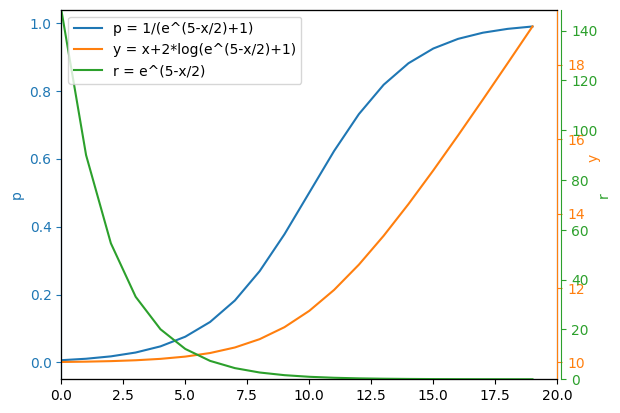

In [4]:
import re

import matplotlib.pyplot as plt
import sympy as sp

# pylint: disable=missing-function-docstring
# ruff: noqa: D103

p, x, y = sp.symbols('p, x, y')
# starting point:
#   p = 1 / (1 + sp.exp(-x))
# move 3 to the right: x ↦ x - 6
# shrink by factor of 2: x - 6 ↦ (x - 6) / 2
moveright = 10
shrink = 2
p = 1 / (1 + sp.exp(-(x-moveright)/shrink))  # type: ignore
y = sp.integrate(p, x)
r = (1-p)/p

def label(eq, text = None):
    l = str(eq.simplify()).replace('**', '^').replace(' ', '').replace('exp', 'e^')
    return f"{text} = {l}" if text else l
def color_ax(ax, which, col, style = '-'):
    ax.spines[which].set_color(col)
    ax.spines[which].set_linestyle(style)
    ax.yaxis.label.set_color(col)
    ax.tick_params(axis='y', colors=col)
def draw_plot(x, y, l, which, col, ax=None):
    if ax is None:
        plt.plot(x, y, label=l, color=col)
    else:
        ax.plot(x, y, label=l, color=col)
    ax = plt.gca()
    plt.ylabel(l[0])
    color_ax(ax, which, col)
    return ax

matplotlib_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

results = []
for x_val in range(-20, 20):
    p_val = p.subs(x, x_val).evalf()
    y_val = y.subs(x, x_val).evalf()
    r_val = r.subs(x, x_val).evalf()
    results.append((x_val, p_val, y_val, r_val))
    print(x_val, p_val, r_val, y_val, r_val)
ax = draw_plot([r[0] for r in results], [r[1] for r in results], label(p, 'p'), 'left', matplotlib_colors[0])
ax.set_xlim([-10+moveright, 10+moveright])
ax2 = ax.twinx()
draw_plot([r[0] for r in results], [r[2] for r in results], label(y, 'y'), 'right', matplotlib_colors[1], ax2)
ax2.yaxis.set_label_coords(1.06, 0.6)
ax3 = ax.twinx()
ax3.yaxis.set_label_coords(1.08, 0.4)
draw_plot([r[0] for r in results], [r[3] for r in results], label(r, 'r'), 'right', matplotlib_colors[2], ax3)
ax3.set_ylim([0, float(max([r[3] for r in results if r[0] in range(-10+moveright, 10+moveright)]))])
ax3.spines['right'].set_position(('outward', 3))
plt.xlabel('x')
legend_labels = [a.get_lines()[0] for a in [ax, ax2, ax3]]
plt.legend(legend_labels, [l.get_label() for l in legend_labels], loc="upper left")
plt.savefig('logistic.png')